# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Isabella Mazzei
* Username: ibmazzei
* Student number: s6253636
* Group (AS1, etc.): AS3
-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

/tmp/ipykernel_926170/4249380186.py:40: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0, np.max(kepler_v))


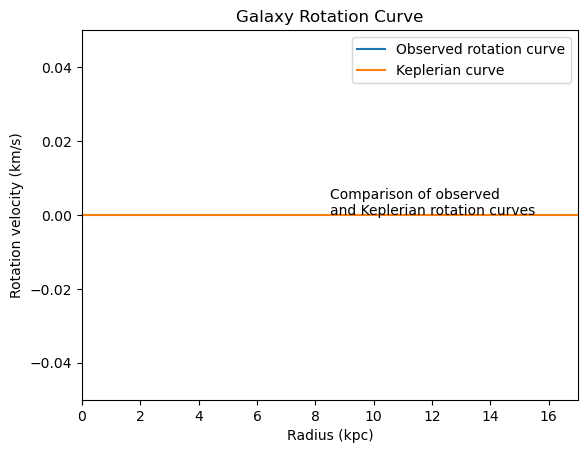

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# load the data from the file
data = np.loadtxt("rotcur.dat.txt")

# separate the columns into two arrays
radius = data[:,0]
velocity = data[:,1]

# calculate the Keplerian rotation curve
# we normalise using the first point so the curve starts at the same value
r0 = radius[0]
v0 = velocity[0]

# so that python can divide by very little numbers I add the 1e-10
kepler_velocity = v0 * np.sqrt(r0 / (radius + 1e-10))

# save the Keplerian curve into a text file
# we save radius and the calculated velocity
kepler_data = np.column_stack((radius, kepler_velocity))
np.savetxt("keplerian_curve.txt", kepler_data)

# load the Keplerian curve again from the saved file
kepler_loaded = np.loadtxt("keplerian_curve.txt")

kepler_radius = kepler_loaded[:,0]
kepler_v = kepler_loaded[:,1]

# create the plot
plt.plot(radius, velocity, label="Observed rotation curve")
plt.plot(kepler_radius, kepler_v, label="Keplerian curve")

# label the axes
plt.xlabel("Radius (kpc)")
plt.ylabel("Rotation velocity (km/s)")

# force axis limits
plt.xlim(0, max(radius))
plt.ylim(0, np.max(kepler_v))

# add a title and legend
plt.title("Galaxy Rotation Curve")
plt.legend()

# add a small annotation on the plot
plt.text(max(radius)*0.5, max(kepler_v)*0.8,
         "Comparison of observed\nand Keplerian rotation curves")

# show the plot
plt.show()


# The observed rotation curve does not follow the Keplerian prediction.
#According to Keplerian dynamics, the rotation velocity should decrease with radius as v=1/r**0.5 .
#However, the data shows that the velocity remains approximately constant at large radii. 
#This discrepancy suggests that additional unseen mass is present in the outer regions of the galaxy.
#This is strong evidence for the existence of dark matter halos surrounding galaxies.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

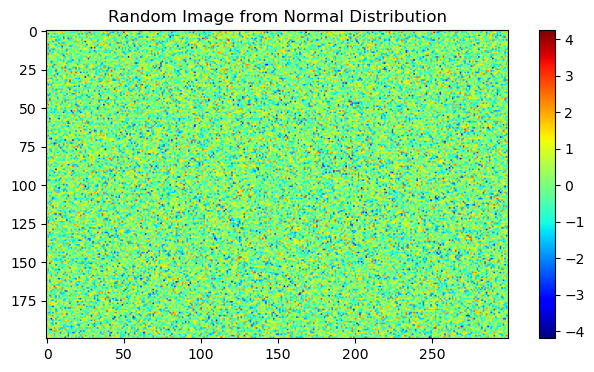

Mean of slice: 0.02604853246491769
Standard deviation of slice: 0.975226344770957


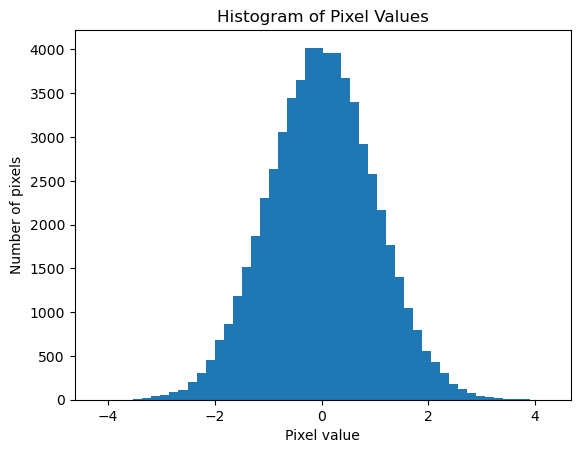

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# create a 2D array with 200 rows and 300 columns
# values are drawn from a normal distribution with mean 0 and std 1
image = np.random.normal(0, 1.0, (200, 300))

# create a figure that is 8 inches wide and 4 inches high
plt.figure(figsize=(8,4))

# display the array as an image
plt.imshow(image, cmap='jet')

# add a colorbar to show the pixel value scale
plt.colorbar()

# add a title
plt.title("Random Image from Normal Distribution")

# show the image
plt.show()


# take a small slice of the image (30x30 pixels)
slice_image = image[50:80, 100:130]

# calculate mean and standard deviation of the slice
slice_mean = np.mean(slice_image)
slice_std = np.std(slice_image)

print("Mean of slice:", slice_mean)
print("Standard deviation of slice:", slice_std)


# flatten the whole image into 1D so we can make a histogram
flat_values = image.ravel()

# create a new figure so it doesn't overlap with the previous plot
plt.figure()

# plot histogram with 50 bins
plt.hist(flat_values, bins=50)

# label the axes
plt.xlabel("Pixel value")
plt.ylabel("Number of pixels")

# add title
plt.title("Histogram of Pixel Values")

# show the histogram
plt.show()

#The mean and standard deviation of the 30×30 slice are close to the expected values of 0 and 1. 
#Small differences occur because the slice contains a limited number of randomly generated pixels

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area: 18.84955592153876
Perimeter: 15.865439589251233
Ellipse center=(0, 0), a=3, b=2, angle=0


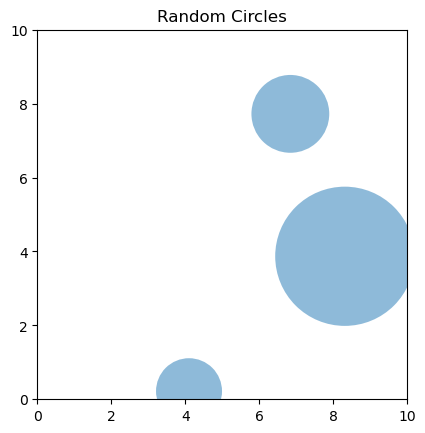

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


class AstroEllipse:

    def __init__(self, center, a, b, angle=0):
        # center of the ellipse (x, y)
        self.center = center
        
        # semi major axis
        self.a = a
        
        # semi minor axis
        self.b = b
        
        # rotation angle
        self.angle = angle


    def area(self):
        # area formula for an ellipse: πab
        area = np.pi * self.a * self.b
        return area


    def perimeter(self):
        # Ramanujan approximation for ellipse perimeter
        a = self.a
        b = self.b
        
        h = ((a - b)**2) / ((a + b)**2)
        perimeter = np.pi * (a + b) * (1 + (3*h) / (10 + np.sqrt(4 - 3*h)))
        
        return perimeter


    def __str__(self):
        # return a string describing the ellipse
        text = f"Ellipse center={self.center}, a={self.a}, b={self.b}, angle={self.angle}"
        return text


# example ellipse
ellipse = AstroEllipse((0,0), 3, 2)

print("Area:", ellipse.area())
print("Perimeter:", ellipse.perimeter())

# demonstrate the __str__ method
print(ellipse)


# class that inherits from AstroEllipse
class MyCircle(AstroEllipse):

    def __init__(self, center, radius):
        # a circle is an ellipse where a = b = radius
        super().__init__(center, radius, radius, angle=0)


# create a plot
fig, ax = plt.subplots()

# three random circles
for i in range(3):
    
    # random center position
    x = np.random.uniform(0,10)
    y = np.random.uniform(0,10)
    
    # random radius
    r = np.random.uniform(0.5,2)
    
    circle = MyCircle((x,y), r)
    
    # create a matplotlib circle patch
    c = patches.Circle((x,y), r, alpha=0.5)
    
    # add circle to the axes
    ax.add_patch(c)


ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_aspect("equal")

plt.title("Random Circles")
plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

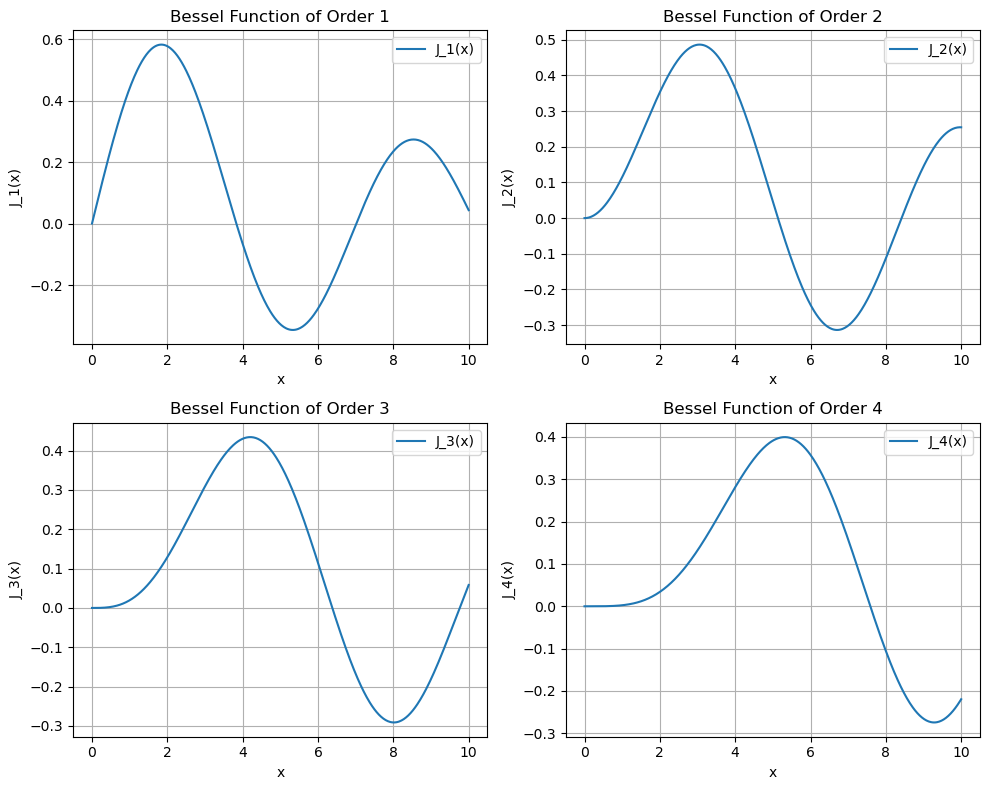

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv  # Bessel function of the first kind

# define x values
x = np.linspace(0, 10, 500)

# Bessel orders we want to plot
orders = [1, 2, 3, 4]

# create a 2x2 mosaic of subplots (object-oriented approach)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# flatten axs to make it easy
axs = axs.flatten()

# loop over orders and axes
for i, a in enumerate(orders):
    y = jv(a, x)  # compute Bessel function of order a
    axs[i].plot(x, y, label=f"J_{a}(x)")
    
    # labels and title for each subplot
    axs[i].set_xlabel("x")
    axs[i].set_ylabel(f"J_{a}(x)")
    axs[i].set_title(f"Bessel Function of Order {a}")
    axs[i].legend()
    axs[i].grid(True)

# adjust layout so titles/labels don't overlap
plt.tight_layout()

# save figure as transparent PNG
plt.savefig("bessel.png", transparent=True)

# show the figure
plt.show()

![Bessel Functions](bessel.png)

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

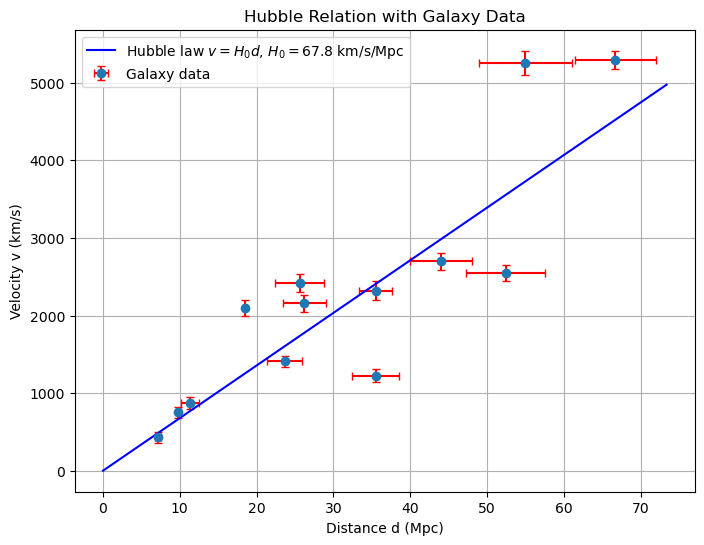

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# raw data in a flat list
data = [
    18.49, 2094.75, 0.3, 100,
    35.48, 2320.87, 2.2, 120,
    35.48, 1224.9, 3.0, 80,
    11.34, 872.13, 1.2, 80,
    7.12, 432.2, 0.4, 70,
    9.82, 751, 0.3, 75,
    23.66, 1410, 2.3, 70,
    44, 2700, 4.0, 110,
    66.7, 5292, 5.3, 120,
    52.4, 2550, 5.2, 100,
    55, 5253, 6.1, 150,
    25.6, 2419, 3.2, 110,
    26.19, 2158, 2.8, 110]

# convert list to numpy array and reshape to columns (each row = one galaxy)
data_array = np.array(data).reshape(-1, 4)

# unpack columns using slicing
distance = data_array[:, 0]       # d(Mpc)
velocity = data_array[:, 1]       # v(km/s)
error_d = data_array[:, 2]        # error in d
error_v = data_array[:, 3]        # error in v

# example Hubble constant
H0 = 67.8  # km/s/Mpc

# create figure and axes using OO interface
fig, ax = plt.subplots(figsize=(8,6))

# plot data with error bars
ax.errorbar(distance, velocity, xerr=error_d, yerr=error_v,
            fmt='o', ecolor='red', capsize=3, label='Galaxy data')

# create a line representing the Hubble law through origin
x_line = np.linspace(0, max(distance)*1.1, 100)
y_line = H0 * x_line
ax.plot(x_line, y_line, 'b-', label=fr'Hubble law $v = H_0 d$, $H_0={H0}$ km/s/Mpc')

# label axes and title
ax.set_xlabel('Distance d (Mpc)')
ax.set_ylabel('Velocity v (km/s)')
ax.set_title('Hubble Relation with Galaxy Data')


ax.legend()
ax.grid(True)
plt.show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
